In [114]:
print('hello')


hello


In [115]:
# ================================
# Contagion Network Notebook Version
# ================================

import networkx as nx
import numpy as np
import pandas as pd
from dataclasses import dataclass
from datetime import datetime
import plotly.graph_objects as go
import networkx as nx

def plot_interactive_network(graph: ContagionGraph):

    G = nx.Graph()

    # Add nodes with attributes
    for node in graph.nodes:
        G.add_node(
            node.id,
            risk=node.risk_score,
            status=node.status,
            sector=node.sector,
            change=node.price_change_pct,
            volume=node.volume_anomaly,
            sentiment=node.sentiment_score
        )

    # Add edges
    for edge in graph.edges:
        G.add_edge(
            edge.source,
            edge.target,
            weight=edge.weight
        )

    pos = nx.spring_layout(G, seed=42)

    # Edge trace
    edge_x = []
    edge_y = []
    edge_text = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
        edge_text.append(f"{u} ↔ {v}<br>Correlation: {G[u][v]['weight']:.2f}")

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        line=dict(width=1),
        hoverinfo='none',
        mode='lines'
    )

    # Node trace
    node_x = []
    node_y = []
    node_color = []
    node_size = []
    node_text = []

    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)

        risk = G.nodes[node]['risk']
        status = G.nodes[node]['status']

        node_size.append(20 + risk * 0.6)

        if status == "healthy":
            node_color.append("green")
        elif status == "stressed":
            node_color.append("orange")
        else:
            node_color.append("red")

        node_text.append(
            f"<b>{node}</b><br>"
            f"Sector: {G.nodes[node]['sector']}<br>"
            f"Risk Score: {risk}<br>"
            f"Status: {status}<br>"
            f"Price Change: {G.nodes[node]['change']}%<br>"
            f"Volume Anomaly: {G.nodes[node]['volume']}<br>"
            f"Sentiment: {G.nodes[node]['sentiment']}"
        )

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode='markers+text',
        hoverinfo='text',
        text=[node for node in G.nodes()],
        textposition="top center",
        hovertext=node_text,
        marker=dict(
            size=node_size,
            color=node_color,
            line=dict(width=1)
        )
    )

    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=f"Interactive Contagion Network | Systemic Risk: {graph.systemic_risk_score}",
            showlegend=False,
            hovermode='closest',
            margin=dict(b=20,l=5,r=5,t=40),
            xaxis=dict(showgrid=False, zeroline=False),
            yaxis=dict(showgrid=False, zeroline=False),
            height=700
        )
    )

    fig.show()

# Contagion Model Parameters
SIR_INFECTION_RATE = 0.3        # Beta: rate of risk propagation
SIR_RECOVERY_RATE = 0.1         # Gamma: rate of risk dissipation
CORRELATION_THRESHOLD = 0.6     # Min correlation to form graph edge
ANOMALY_ZSCORE_THRESHOLD = 2.0  # Z-score threshold for anomaly detection

# Optional reproducibility
np.random.seed(42)

# -----------------------------
# Data Models (replace schemas)
# -----------------------------
@dataclass
class GraphNode:
    id: str
    label: str
    sector: str
    risk_score: float
    status: str
    price_change_pct: float
    volume_anomaly: bool
    sentiment_score: float


@dataclass
class GraphEdge:
    source: str
    target: str
    weight: float
    contagion_risk: float


@dataclass
class ContagionGraph:
    nodes: List[GraphNode]
    edges: List[GraphEdge]
    timestamp: datetime
    systemic_risk_score: float


# -----------------------------
# Sector Mapping
# -----------------------------
TICKER_SECTORS = {
    "JPM": "Major Banks", "BAC": "Major Banks", "C": "Major Banks",
    "WFC": "Major Banks", "GS": "Major Banks", "MS": "Major Banks",
    "DB": "Major Banks", "UBS": "Major Banks", "CS": "Major Banks",
    "HSBC": "Major Banks",
    "SCHW": "Regional Banks", "USB": "Regional Banks", "PNC": "Regional Banks",
    "TFC": "Regional Banks", "FITB": "Regional Banks",
    "BRK-B": "Insurance/Financial", "AIG": "Insurance/Financial",
    "MET": "Insurance/Financial", "PRU": "Insurance/Financial",
    "SPY": "Equity Index", "QQQ": "Equity Index", "IWM": "Equity Index",
    "EFA": "Equity Index", "EEM": "Equity Index",
    "TLT": "Fixed Income", "HYG": "Fixed Income", "LQD": "Fixed Income",
    "AGG": "Fixed Income",
    "GLD": "Commodities", "USO": "Commodities", "UNG": "Commodities",
    "BITO": "Crypto",
    "UVXY": "Volatility",
    "UUP": "FX", "FXE": "FX", "FXY": "FX",
}

# -----------------------------
# Core Functions
# -----------------------------
def build_contagion_graph(
    correlation_matrix: pd.DataFrame,
    market_data: pd.DataFrame,
    threshold: float = CORRELATION_THRESHOLD,
    sentiment_data: Optional[dict[str, float]] = None,
) -> ContagionGraph:
    
    G = nx.Graph()
    sentiment_data = sentiment_data or {}

    # Market lookup (cleaned)
    market_lookup = {
        row["ticker"]: row for _, row in market_data.iterrows()
    } if not market_data.empty else {}

    nodes = []

    for ticker in correlation_matrix.columns:
        md = market_lookup.get(ticker, {})

        change_pct = float(md.get("change_pct", 0))
        vol_ratio = float(md.get("volume_ratio", 1))
        ticker_sentiment = sentiment_data.get(ticker, 0.0)

        risk_score = _compute_node_risk_score(change_pct, vol_ratio, ticker_sentiment)
        status = _risk_to_status(risk_score)
        volume_anomaly = vol_ratio > 2.0

        node = GraphNode(
            id=ticker,
            label=ticker,
            sector=TICKER_SECTORS.get(ticker, "Other"),
            risk_score=risk_score,
            status=status,
            price_change_pct=change_pct,
            volume_anomaly=volume_anomaly,
            sentiment_score=ticker_sentiment,
        )

        nodes.append(node)
        G.add_node(ticker, risk_score=risk_score)

    # Build edges safely using label-based indexing
    edges = []
    tickers = list(correlation_matrix.columns)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            corr = abs(correlation_matrix.loc[tickers[i], tickers[j]])

            if corr >= threshold:
                source_risk = G.nodes[tickers[i]]["risk_score"] / 100
                contagion_risk = min(corr * source_risk * SIR_INFECTION_RATE, 1.0)

                edge = GraphEdge(
                    source=tickers[i],
                    target=tickers[j],
                    weight=round(float(corr), 3),
                    contagion_risk=round(contagion_risk, 3),
                )

                edges.append(edge)
                G.add_edge(tickers[i], tickers[j], weight=corr)

    # # Systemic risk via PageRank
    # if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
    #     pagerank = nx.pagerank(G, weight="weight")
    #     systemic_risk = sum(
    #         pagerank.get(n.id, 0) * n.risk_score for n in nodes
    #     )
    #     systemic_risk = min(systemic_risk * 2, 100)
    # else:
    #     systemic_risk = 0.0

    systemic_risk = -1

    return ContagionGraph(
        nodes=nodes,
        edges=edges,
        timestamp=datetime.now(),
        systemic_risk_score=round(systemic_risk, 1),
    )


def simulate_contagion_spread(
    graph: ContagionGraph,
    shock_node: str,
    shock_magnitude: float = 0.8,
    steps: int = 10,
) -> list[dict]:

    states = {}

    for node in graph.nodes:
        if node.id == shock_node:
            states[node.id] = {
                "state": "infected",
                "risk": min(node.risk_score + shock_magnitude * 100, 100),
            }
        else:
            states[node.id] = {
                "state": "susceptible",
                "risk": node.risk_score,
            }

    adjacency = {}
    for edge in graph.edges:
        adjacency.setdefault(edge.source, []).append((edge.target, edge.weight))
        adjacency.setdefault(edge.target, []).append((edge.source, edge.weight))

    snapshots = [_state_snapshot(states, 0)]

    for step in range(1, steps + 1):
        new_states = {k: dict(v) for k, v in states.items()}

        for node_id, state in states.items():
            if state["state"] == "infected":

                # Loop through all connected neighbours
                # If neigbour is suspectible, then calculating infection probablity
                # weight = corr weight, how strongly it is connected to neighbour
                
                for neighbor, weight in adjacency.get(node_id, []):
                    if states[neighbor]["state"] == "susceptible":
                        infection_prob = weight * SIR_INFECTION_RATE * (state["risk"] / 100)
                        
                        # Stochastic infection model: Binary outcome per step (infected or not)
                        # If we replace randomness with multiplication, you move to:Deterministic expected-value risk propagation
                        
                        if np.random.random() < infection_prob:
                            new_states[neighbor]["state"] = "infected"
                            
                            # if new neighour is infected, increase risk by half of weight exposure, transferring partial distress
                            risk_increase = state["risk"] * weight * 0.5 

                            # cap risk at 100, prevent runaway values
                            new_states[neighbor]["risk"] = min(
                                new_states[neighbor]["risk"] + risk_increase, 100
                            )

                recovery_fn = stochastic_recovery

                if state["state"] == "infected":
                    recovery_fn(node_id, state, new_states, SIR_RECOVERY_RATE)

                # if np.random.random() < SIR_RECOVERY_RATE:
                #     new_states[node_id]["state"] = "recovered"

                #     # Risk Reduction on recovery to represent capital injection, liquidity support, policy intervention etc
                #     new_states[node_id]["risk"] = max(state["risk"] * 0.7, 10)

        states = new_states
        snapshots.append(_state_snapshot(states, step))

    return snapshots


# -----------------------------
# Helper Functions
# -----------------------------
def _state_snapshot(states: dict, step: int) -> dict:
    return {
        "step": step,
        "states": {
            node_id: {
                "state": s["state"],
                "risk": round(s["risk"], 1),
            }
            for node_id, s in states.items()
        },
        "infected_count": sum(1 for s in states.values() if s["state"] == "infected"),
        "total_risk": round(sum(s["risk"] for s in states.values()), 1),
    }

def _compute_node_risk_score(change_pct: float, vol_ratio: float, sentiment_score: float = 0.0) -> float:
    price_risk = min(abs(change_pct) * 10, 50) if change_pct < 0 else max(0, abs(change_pct) * 3 - 5)
    volume_risk = min((vol_ratio - 1) * 15, 50) if vol_ratio > 1.5 else 0

    # if sentiment_score < 0:
    #     sentiment_risk = min(abs(sentiment_score) * 25, 25)
    # elif sentiment_score > 0:
    #     sentiment_risk = -min(sentiment_score * 10, 10)
    # else:
    #     sentiment_risk = 0

    # score is ranged betwee 0 and 100
    return min(max(round(price_risk + volume_risk, 1), 0), 100)


def _risk_to_status(risk_score: float) -> str:
    if risk_score < 25:
        return "healthy"
    elif risk_score < 60:
        return "stressed"
    else:
        return "critical"


def deterministic_expected_infection(node_id, neighbor, weight, state, new_states, SIR_INFECTION_RATE):
    """
    Deterministic expected-value infection model.
    Risk transfer scaled by infection probability.
    """

    infection_prob = weight * SIR_INFECTION_RATE * (state["risk"] / 100)

    risk_increase = state["risk"] * weight * 0.5 * infection_prob

    new_states[neighbor]["risk"] = min(
        new_states[neighbor]["risk"] + risk_increase,
        100
    )

    # Optional threshold to flip state
    if new_states[neighbor]["risk"] >= 80:
        new_states[neighbor]["state"] = "infected"


def stochastic_infection(node_id, neighbor, weight, state, new_states, SIR_INFECTION_RATE):
    """
    Probabilistic infection model.
    Infection occurs with probability proportional to:
    weight × SIR_INFECTION_RATE × (risk / 100)
    """

    infection_prob = weight * SIR_INFECTION_RATE * (state["risk"] / 100)

    if np.random.random() < infection_prob:
        new_states[neighbor]["state"] = "infected"

        risk_increase = state["risk"] * weight * 0.5
        new_states[neighbor]["risk"] = min(
            new_states[neighbor]["risk"] + risk_increase,
            100
        )


def stochastic_recovery(node_id, state, new_states, SIR_RECOVERY_RATE):
    """
    Probabilistic recovery.
    Node recovers with probability SIR_RECOVERY_RATE.
    Risk reduced by 30%, floor at 10.
    """

    if np.random.random() < SIR_RECOVERY_RATE:
        new_states[node_id]["state"] = "recovered"

        new_states[node_id]["risk"] = max(
            state["risk"] * 0.7,
            10
        )


def deterministic_recovery(node_id, state, new_states, SIR_RECOVERY_RATE):
    """
    Deterministic recovery using expected-value decay.
    Risk decays smoothly each step.
    """

    decay_factor = 1 - (1 - 0.7) * SIR_RECOVERY_RATE  # 1 - 0.3 * rate

    new_risk = max(
        state["risk"] * decay_factor,
        10
    )

    new_states[node_id]["risk"] = new_risk

    # Optional: switch to recovered once risk stabilizes
    if new_risk <= 70:
        new_states[node_id]["state"] = "recovered"

In [118]:
#Simple Mock Data
import pandas as pd

tickers = ["JPM", "BAC", "GS"]

corr_matrix_simple = pd.DataFrame(
    [[1.0, 0.7, 0.5],
     [0.7, 1.0, 0.8],
     [0.5, 0.8, 1.0]],
    columns=tickers,
    index=tickers
)

market_data_simple = pd.DataFrame([
    {"ticker": "JPM", "change_pct": -2.5, "volume_ratio": 2.3},
    {"ticker": "BAC", "change_pct": -1.2, "volume_ratio": 1.8},
    {"ticker": "GS", "change_pct": 0.5, "volume_ratio": 1.1},
])

In [43]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_contagion_graph(graph: ContagionGraph):
    
    G = nx.Graph()

    # Add nodes
    for node in graph.nodes:
        G.add_node(
            node.id,
            risk=node.risk_score,
            status=node.status
        )

    # Add edges
    for edge in graph.edges:
        G.add_edge(edge.source, edge.target, weight=edge.weight)

    # Layout (stable positioning)
    pos = nx.spring_layout(G, seed=42)

    # Node sizes scale with risk
    node_sizes = [
        300 + (G.nodes[n]["risk"] * 15)
        for n in G.nodes()
    ]

    # Color mapping by status
    color_map = []
    for n in G.nodes():
        status = G.nodes[n]["status"]
        if status == "healthy":
            color_map.append("green")
        elif status == "stressed":
            color_map.append("orange")
        else:
            color_map.append("red")

    plt.figure(figsize=(10, 8))

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=color_map,
        alpha=0.9
    )

    # Draw edges
    nx.draw_networkx_edges(
        G, pos,
        width=[G[u][v]['weight'] * 3 for u, v in G.edges()],
        alpha=0.5
    )

    # Labels
    nx.draw_networkx_labels(G, pos, font_size=10)

    # Edge labels (correlations)
    edge_labels = {
        (u, v): round(G[u][v]['weight'], 2)
        for u, v in G.edges()
    }

    # nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels={}, font_size=8)

    # plt.title(f"Contagion Network | Systemic Risk: {graph.systemic_risk_score}")
    plt.title(f"Contagion Network")
    plt.axis("off")
    plt.show()



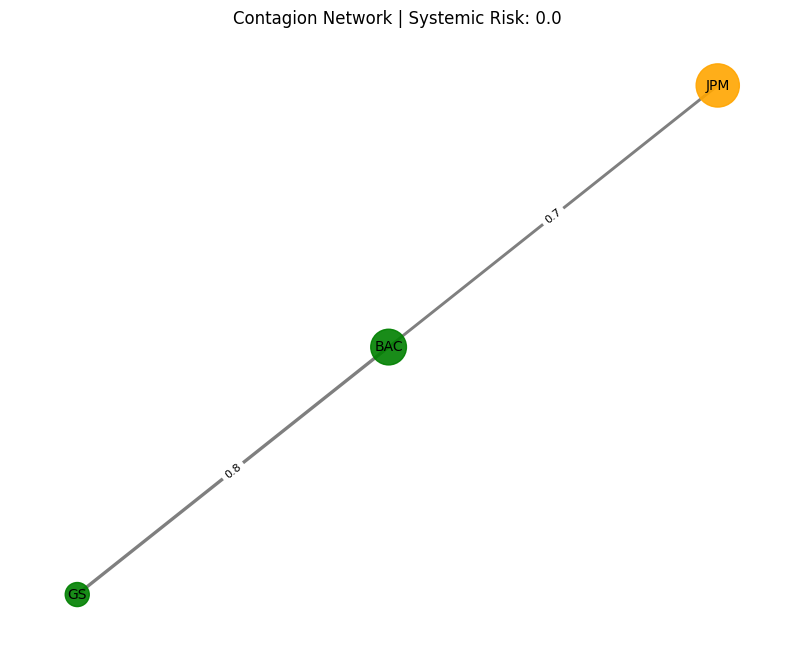

In [5]:
visualize_contagion_graph(graph)


In [123]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
from IPython.display import HTML

def animate_contagion(graph, snapshots):

    if len(snapshots) == 0:
        print("No snapshots to animate.")
        return

    G = nx.Graph()
    for node in graph.nodes:
        G.add_node(node.id)

    for edge in graph.edges:
        G.add_edge(edge.source, edge.target, weight=edge.weight)

    pos = nx.spring_layout(G, seed=42)

    fig, ax = plt.subplots(figsize=(8, 6))

    def update(frame):
        ax.clear()
        snapshot = snapshots[frame]
        states = snapshot["states"]

        colors = []
        sizes = []

        for node in G.nodes():
            state = states[node]["state"]
            risk = states[node]["risk"]

            if state == "susceptible":
                colors.append("lightblue")
            elif state == "infected":
                colors.append("red")
            else:
                colors.append("green")

            sizes.append(300 + risk * 10)

        nx.draw(
            G,
            pos,
            node_color=colors,
            node_size=sizes,
            with_labels=True,
            ax=ax
        )

        ax.set_title(
            f"Step {snapshot['step']} | "
            f"Infected: {snapshot['infected_count']}"
        )
        ax.axis("off")

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(snapshots),
        interval=800,
        repeat=False
    )

    plt.close(fig)

    # THIS is the important line for your environment:
    return HTML(ani.to_jshtml())


def plot_annotated_heatmap(corr_matrix):
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(corr_matrix.values, norm=norm)
    
    fig.colorbar(im, ax=ax)
    
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))
    
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix.index)
    
    # Add annotations
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            ax.text(
                j, i,
                f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )
    
    ax.set_title("Annotated Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
len(snapshots)

In [120]:
snapshots = simulate_contagion_spread(graph, shock_node="JPM", steps=8)
print(len(snapshots))
animate_contagion(graph, snapshots)

9


In [124]:
# -----------------------------
# Deep Contagion Stress Dataset
# -----------------------------

tickers = [
    # Major Banks
    "JPM", "BAC", "GS", "MS",
    
    # Regional Banks
    "USB", "PNC", "TFC",
    
    # Market ETFs
    "SPY", "QQQ", "IWM",
    
    # Defensive
    "TLT", "GLD"
]

n = len(tickers)

# Start with identity matrix
corr_matrix = pd.DataFrame(
    np.eye(n),
    columns=tickers,
    index=tickers
)

# -----------------------------
# 1️⃣ Major Bank Cluster (Very High Correlation)
# -----------------------------
major_banks = ["JPM", "BAC", "GS", "MS"]

for i in major_banks:
    for j in major_banks:
        if i != j:
            corr_matrix.loc[i, j] = 0.82

# -----------------------------
# 2️⃣ Regional Bank Cluster
# -----------------------------
regional_banks = ["USB", "PNC", "TFC"]

for i in regional_banks:
    for j in regional_banks:
        if i != j:
            corr_matrix.loc[i, j] = 0.78

# -----------------------------
# 3️⃣ Bank ↔ Regional Bridge
# -----------------------------
for i in major_banks:
    for j in regional_banks:
        corr_matrix.loc[i, j] = 0.65
        corr_matrix.loc[j, i] = 0.65

# -----------------------------
# 4️⃣ Market ETF Cluster
# -----------------------------
etfs = ["SPY", "QQQ", "IWM"]

for i in etfs:
    for j in etfs:
        if i != j:
            corr_matrix.loc[i, j] = 0.85

# -----------------------------
# 5️⃣ SPY As Systemic Bridge
# -----------------------------
for bank in major_banks + regional_banks:
    corr_matrix.loc["SPY", bank] = 0.72
    corr_matrix.loc[bank, "SPY"] = 0.72

# -----------------------------
# 6️⃣ Defensive Assets (Negative / Low Correlation)
# -----------------------------
for bank in major_banks + regional_banks:
    corr_matrix.loc["TLT", bank] = -0.35
    corr_matrix.loc[bank, "TLT"] = -0.35
    
    corr_matrix.loc["GLD", bank] = -0.25
    corr_matrix.loc[bank, "GLD"] = -0.25

# Moderate defensive linkage
corr_matrix.loc["TLT", "GLD"] = 0.55
corr_matrix.loc["GLD", "TLT"] = 0.55

# Low ETF ↔ Defensive
for etf in etfs:
    corr_matrix.loc["TLT", etf] = -0.20
    corr_matrix.loc[etf, "TLT"] = -0.20
    
    corr_matrix.loc["GLD", etf] = -0.15
    corr_matrix.loc[etf, "GLD"] = -0.15

print(corr_matrix)

      JPM   BAC    GS    MS   USB   PNC   TFC   SPY   QQQ   IWM   TLT   GLD
JPM  1.00  0.82  0.82  0.82  0.65  0.65  0.65  0.72  0.00  0.00 -0.35 -0.25
BAC  0.82  1.00  0.82  0.82  0.65  0.65  0.65  0.72  0.00  0.00 -0.35 -0.25
GS   0.82  0.82  1.00  0.82  0.65  0.65  0.65  0.72  0.00  0.00 -0.35 -0.25
MS   0.82  0.82  0.82  1.00  0.65  0.65  0.65  0.72  0.00  0.00 -0.35 -0.25
USB  0.65  0.65  0.65  0.65  1.00  0.78  0.78  0.72  0.00  0.00 -0.35 -0.25
PNC  0.65  0.65  0.65  0.65  0.78  1.00  0.78  0.72  0.00  0.00 -0.35 -0.25
TFC  0.65  0.65  0.65  0.65  0.78  0.78  1.00  0.72  0.00  0.00 -0.35 -0.25
SPY  0.72  0.72  0.72  0.72  0.72  0.72  0.72  1.00  0.85  0.85 -0.20 -0.15
QQQ  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.85  1.00  0.85 -0.20 -0.15
IWM  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.85  0.85  1.00 -0.20 -0.15
TLT -0.35 -0.35 -0.35 -0.35 -0.35 -0.35 -0.35 -0.20 -0.20 -0.20  1.00  0.55
GLD -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.15 -0.15 -0.15  0.55  1.00


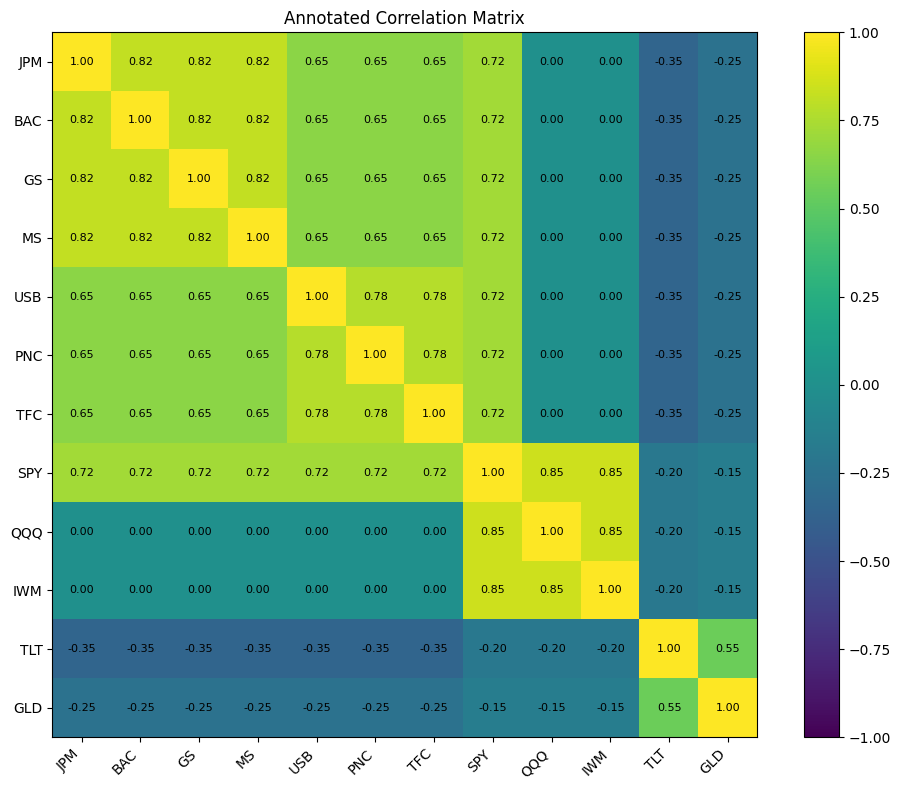

In [125]:
plot_annotated_heatmap(corr_matrix)

In [126]:
market_data = pd.DataFrame([
    # Major banks hit hard
    {"ticker": "JPM", "change_pct": -3.8, "volume_ratio": 2.5},
    {"ticker": "BAC", "change_pct": -4.1, "volume_ratio": 2.7},
    {"ticker": "GS", "change_pct": -2.9, "volume_ratio": 2.2},
    {"ticker": "MS", "change_pct": -3.2, "volume_ratio": 2.4},
    
    # Regional banks worse
    {"ticker": "USB", "change_pct": -5.5, "volume_ratio": 3.0},
    {"ticker": "PNC", "change_pct": -4.8, "volume_ratio": 2.8},
    {"ticker": "TFC", "change_pct": -5.1, "volume_ratio": 2.9},
    
    # Market ETFs
    {"ticker": "SPY", "change_pct": -2.5, "volume_ratio": 1.9},
    {"ticker": "QQQ", "change_pct": -3.0, "volume_ratio": 2.0},
    {"ticker": "IWM", "change_pct": -3.6, "volume_ratio": 2.2},
    
    # Flight to safety
    {"ticker": "TLT", "change_pct": 1.8, "volume_ratio": 1.6},
    {"ticker": "GLD", "change_pct": 1.2, "volume_ratio": 1.4},
])

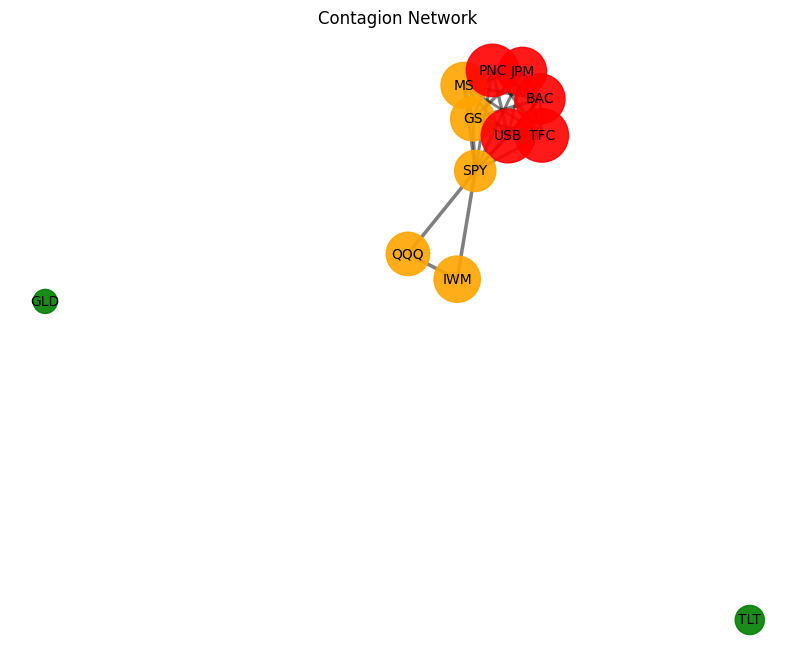

In [128]:
graph = build_contagion_graph(corr_matrix, market_data)

visualize_contagion_graph(graph)


In [129]:
# -----------------------------
# S&P 500 Sector-Based Matrix - Working Demo Example
# -----------------------------

sectors = {
    "Tech": ["AAPL", "MSFT", "NVDA", "GOOGL", "META"],
    "Financials": ["JPM", "BAC", "GS", "MS", "C"],
    "Consumer": ["AMZN", "TSLA", "HD", "NKE", "MCD"],
    "Healthcare": ["JNJ", "PFE", "UNH", "MRK", "LLY"],
    "Energy": ["XOM", "CVX", "SLB", "COP", "PSX"]
}

vix = ["VIX"]

tickers_sp = sum(sectors.values(), []) + vix
n = len(tickers_sp)

corr_sp = pd.DataFrame(
    np.eye(n),
    columns=tickers_sp,
    index=tickers_sp
)

# Intra-sector high correlation
for sector, names in sectors.items():
    for i in names:
        for j in names:
            if i != j:
                corr_sp.loc[i, j] = np.random.uniform(0.75, 0.85)

# Cross-sector moderate correlation
for s1 in sectors.values():
    for s2 in sectors.values():
        if s1 != s2:
            for i in s1:
                for j in s2:
                    corr_sp.loc[i, j] = np.random.uniform(0.35, 0.55)

# Add VIX negative correlation
for ticker in tickers_sp:
    if ticker != "VIX":
        corr_sp.loc["VIX", ticker] = -0.65
        corr_sp.loc[ticker, "VIX"] = -0.65

corr_sp.loc["VIX", "VIX"] = 1.0

# Hackathon flow

#First need the entire download of S&P 500 with its sector - give us the ability to a create a correlation matrix using a fn or use LLM
#Ability to select on the fly which index we want (if judges world market, "MSCI World Index")
#extension: get 10yr prices, format this data, python.corr_matrix(prices)


#flow: type in the index, get the consitituents and sector, build the correlation matrix on the fly
#market change: change in price and volume (to calc volume ratio) 
#extension (sentiment -> feed in the score)

#simulate a contagion scenario - LLM can generate 50 different scenarios based on market news
#e.g. simulatino: shock JPM, and see the affected to the interwinted companies
#LLM - to get sector level analysis and supplement the visualiation with this 

#FRED API - if there is a change in treasury yield curve, or cahnge in job market data we can explain this

#Infrastructure -



In [136]:
graph_contagion = build_contagion_graph(corr_sp, market_data)

In [131]:
import pandas as pd

def contagion_with_risk_table(snapshots):
    records = {}

    for snapshot in snapshots:
        step = snapshot["step"]
        states = snapshot["states"]

        for node, attrs in states.items():
            state = attrs["state"]
            risk = attrs["risk"]

            if node not in records:
                records[node] = {}

            records[node][f"Step_{step}"] = f"{state} ({risk})"

    df = pd.DataFrame.from_dict(records, orient="index")
    df.index.name = "Institution"
    
    # Optional: sort alphabetically
    df = df.sort_index()
    
    return df

In [139]:
# DEMO Example

graph_contagion_snapshots = simulate_contagion_spread(graph_contagion, shock_node="MS", steps=6)

display(contagion_with_risk_table(graph_contagion_snapshots))
animate_contagion(graph_contagion, graph_contagion_snapshots)


,Step_0,Step_1,Step_2,Step_3,Step_4,Step_5,Step_6
Institution,,,,,,,
AAPL,susceptible (0),susceptible (0),susceptible (0),infected (10.6),infected (10.6),infected (10.6),infected (10.6)
AMZN,susceptible (0),susceptible (0),susceptible (0),susceptible (0),infected (10.6),infected (10.6),infected (10.6)
BAC,susceptible (66.5),susceptible (66.5),susceptible (66.5),infected (100),infected (100),infected (100),infected (100)
C,susceptible (0),susceptible (0),infected (39.1),infected (39.1),infected (39.1),infected (39.1),infected (39.1)
COP,susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0)
CVX,susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0)
GOOGL,susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0)
GS,susceptible (47.0),susceptible (47.0),susceptible (47.0),susceptible (47.0),susceptible (47.0),susceptible (47.0),susceptible (47.0)
HD,susceptible (0),susceptible (0),infected (10.6),infected (10.6),infected (10.6),infected (10.6),recovered (10)


In [ ]:
visualize_contagion_graph(graph_contagion)
plot_annotated_heatmap(corr_sp)

In [39]:
def generate_synthetic_correlation(
    n_nodes=20,
    n_clusters=4,
    intra_corr=0.85,
    inter_corr=0.40,
    crisis_multiplier=1.0
):
    
    tickers = [f"Asset_{i}" for i in range(n_nodes)]
    
    corr = pd.DataFrame(
        np.eye(n_nodes),
        columns=tickers,
        index=tickers
    )
    
    cluster_size = n_nodes // n_clusters
    
    clusters = []
    for i in range(n_clusters):
        clusters.append(
            tickers[i*cluster_size:(i+1)*cluster_size]
        )
    
    # Intra-cluster
    for cluster in clusters:
        for i in cluster:
            for j in cluster:
                if i != j:
                    corr.loc[i, j] = intra_corr * crisis_multiplier
    
    # Inter-cluster
    for c1 in clusters:
        for c2 in clusters:
            if c1 != c2:
                for i in c1:
                    for j in c2:
                        corr.loc[i, j] = inter_corr * crisis_multiplier
    
    return corr

Systemic Risk Score: -1


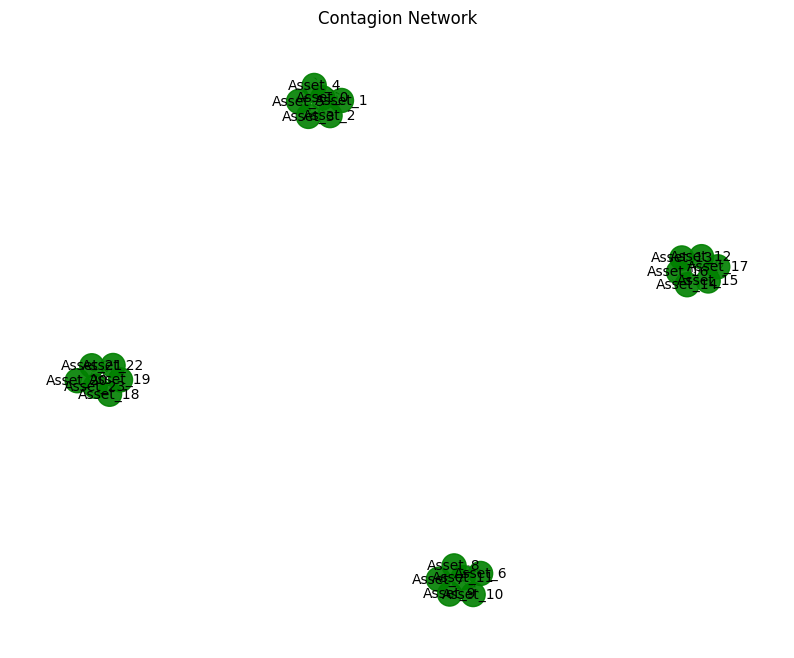

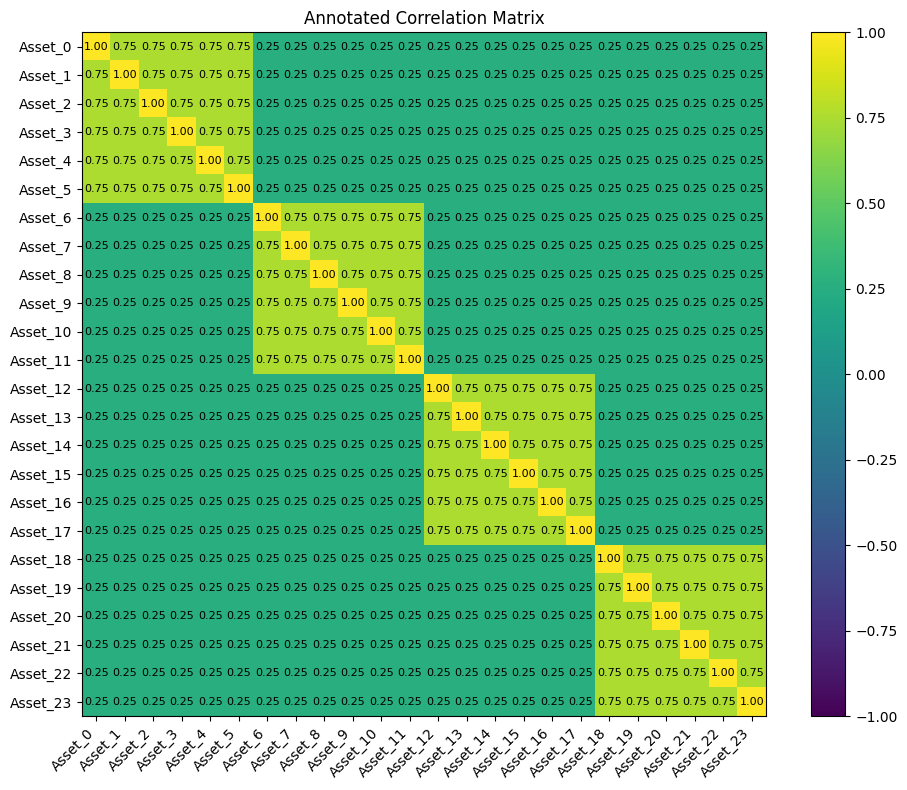

In [41]:
corr_synthetic_normal = generate_synthetic_correlation(
    n_nodes=24,
    n_clusters=4,
    intra_corr=0.75,
    inter_corr=0.25,
    crisis_multiplier=1.0
)

graph_corr_synthetic_normal = build_contagion_graph(corr_synthetic_normal, market_data)

print("Systemic Risk Score:", graph.systemic_risk_score)

visualize_contagion_graph(graph_corr_synthetic_normal)
plot_annotated_heatmap(corr_synthetic_normal)

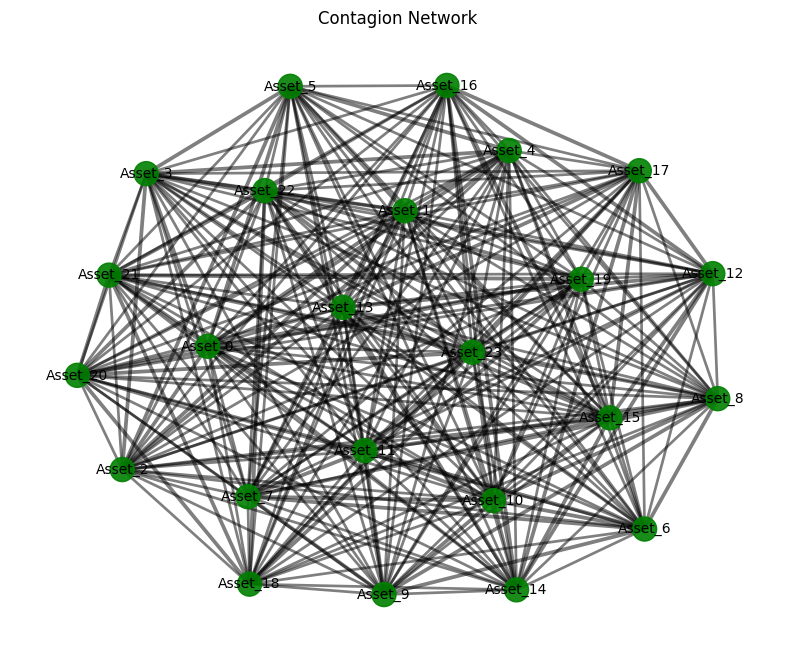

,Step_0,Step_1,Step_2,Step_3,Step_4,Step_5,Step_6,Step_7,Step_8,Step_9,Step_10
Institution,,,,,,,,,,,
Asset_0,susceptible (0),susceptible (0),infected (26.0),infected (26.0),infected (26.0),infected (26.0),infected (26.0),infected (26.0),infected (26.0),recovered (18.2),recovered (18.2)
Asset_1,susceptible (0),susceptible (0),susceptible (0),susceptible (0),susceptible (0),infected (5.3),infected (5.3),infected (5.3),infected (5.3),recovered (10),recovered (10)
Asset_10,susceptible (0),susceptible (0),susceptible (0),infected (20.2),infected (20.2),infected (20.2),infected (20.2),infected (20.2),infected (20.2),infected (20.2),infected (20.2)
Asset_11,susceptible (0),susceptible (0),infected (8.5),infected (8.5),infected (8.5),infected (8.5),recovered (10),recovered (10),recovered (10),recovered (10),recovered (10)
Asset_12,susceptible (0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0)
Asset_13,susceptible (0),susceptible (0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),infected (36.0)
Asset_14,susceptible (0),susceptible (0),susceptible (0),infected (32.4),infected (32.4),infected (32.4),infected (32.4),infected (32.4),infected (32.4),infected (32.4),infected (32.4)
Asset_15,susceptible (0),susceptible (0),infected (36.0),infected (36.0),infected (36.0),infected (36.0),recovered (25.2),recovered (25.2),recovered (25.2),recovered (25.2),recovered (25.2)
Asset_16,infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0),infected (80.0)


In [135]:
corr_synthetic_crisis = generate_synthetic_correlation(
    n_nodes=24,
    n_clusters=4,
    intra_corr=0.90,
    inter_corr=0.65,
    crisis_multiplier=1.0
)

graph_corr_synthetic_crisis = build_contagion_graph(corr_synthetic_crisis, market_data)

visualize_contagion_graph(graph_corr_synthetic_crisis)


graph_corr_synthetic_crisis_snapshots = simulate_contagion_spread(graph_corr_synthetic_crisis, shock_node="Asset_16", steps=10)

display(contagion_with_risk_table(graph_corr_synthetic_crisis_snapshots))
animate_contagion(graph_corr_synthetic_crisis, graph_corr_synthetic_crisis_snapshots)